# Task 2:  Standard Apriori 

### Requirements
1.	Write a function to generate all frequent itemsets of size 1 (i.e., all individual items that meet the minimum support threshold). Also print pruned and qualified itemsets of size 1. 
2.	Write a function to generate all frequent itemsets of size k (where k > 1) using the frequent itemsets of size k-1 and the Apriori property. Also print pruned and qualified itemsets of size k. 
3.	Apply Apriori algorithm on given dataset. Find all frequent itemsets using minimum Support and Confidence.  
    - Show candidates & qualified items at each level. 
    - Identify Strong and Weak rules with confidence threshold of 80%. 

---------------------



In [13]:
# Import required libraries
import pandas as pd
import itertools
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np


In [14]:
# Load the preprocessed dataset

df = pd.read_csv('../../data/processed/preprocessed_data.csv')

print(f"Dataset Preview: ")
print(df.head(10))

print(f"\nDataset Shape: {df.shape}")

Dataset Preview: 
   Unnamed: 0  Invoice StockCode                          Description  \
0           0   536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER   
1           1   536365     71053                  WHITE METAL LANTERN   
2           2   536365    84406B       CREAM CUPID HEARTS COAT HANGER   
3           3   536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE   
4           4   536365    84029E       RED WOOLLY HOTTIE WHITE HEART.   
5           5   536365     22752         SET 7 BABUSHKA NESTING BOXES   
6           6   536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER   
7           7   536366     22633               HAND WARMER UNION JACK   
8           8   536366     22632            HAND WARMER RED POLKA DOT   
9           9   536368     22960             JAM MAKING SET WITH JARS   

   Quantity          InvoiceDate  
0         6  2010-12-01 08:26:00  
1         6  2010-12-01 08:26:00  
2         8  2010-12-01 08:26:00  
3         6  2010-12-01 08:26:00  
4  

In [15]:
# Convert to transaction format grouped by Invoice

print("=" * 80)
print(f"CREATE TRANSACTION FORMAT: ")
print("=" * 80)

transactions = []
transaction_ids = []

# Group items by Invoice number maintaining on non-empty transactions
for invoice, group in df.groupby('Invoice'):
    items = set(group['Description'].unique())
    if len(items) > 0:
        transactions.append(items)
        transaction_ids.append(invoice)

# Count total transactions from the dataset
print(f"Transactions Summary: ")
total_transactions = len(transactions)
print(f"- Total Transaction Count: {total_transactions}")

# Show sample transactions
print(f"\nSample Transactions: ")
for i in range(min(5, len(transactions))):
    item_list = list(transactions[i])
    print(f" Transaction {transaction_ids[i]}: {item_list[:5]}: {''if len(item_list) > 5 else ''}({len(item_list)} items)")


CREATE TRANSACTION FORMAT: 
Transactions Summary: 
- Total Transaction Count: 1802

Sample Transactions: 
 Transaction 536365: ['WHITE HANGING HEART T-LIGHT HOLDER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'SET 7 BABUSHKA NESTING BOXES', 'RED WOOLLY HOTTIE WHITE HEART.']: (7 items)
 Transaction 536366: ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT']: (2 items)
 Transaction 536367: ["POPPY'S PLAYHOUSE KITCHEN", "POPPY'S PLAYHOUSE BEDROOM", 'BOX OF VINTAGE ALPHABET BLOCKS', 'LOVE BUILDING BLOCK WORD', 'IVORY KNITTED MUG COSY']: (12 items)
 Transaction 536368: ['YELLOW COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION', 'JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION']: (4 items)
 Transaction 536369: ['BATH BUILDING BLOCK WORD']: (1 items)


In [17]:
# Define algorithm parameters
print("=" * 80)
print(f"ALGORITHM PARAMETERS: ")
print("=" * 80)

MIN_SUPPORT = 0.02      # 2% minimum support
MIN_CONFIDENCE = 0.80   # 80% confidence threshold
MAX_K = 5               # Maximum itemset size

# Caluclate for absolute minimum support count
min_support_count = int(MIN_SUPPORT * total_transactions)

print(f"- Minimum Support Ratio: {MIN_SUPPORT * 100}%")
print(f"- Total Transactions: {total_transactions}")
print(f"- Minimum Support Count: {min_support_count} transactions")
print(f"- Minimum Confidence: {MIN_CONFIDENCE * 100}%")
print(f"- Maximum Itemset Size (k): {MAX_K}")

ALGORITHM PARAMETERS: 
- Minimum Support Ratio: 2.0%
- Total Transactions: 1802
- Minimum Support Count: 36 transactions
- Minimum Confidence: 80.0%
- Maximum Itemset Size (k): 5


In [18]:
# 2.1: Function to Generate Frequent 1-Itemsets

def generate_frequent_1_itemsets(transactions, min_support_count, verbose=True):
    """
    Generate all frequent individual items (1-itemsets) from the produced transaction list
    
    Params:
    - transactions: list of sets - where each element is a set of items in a transaction
    - min_support_count: int - minimum suppoert threshold 
    - verbose: bool - print detailed output for analysis

    Returns:
    1. frequent_1_itemsets: dict - with itemsets as keys (frozenset) and support caounts as values
    2. pruned_itemets: dict - with pruned itemsets and counts
    """
    print(f"\n" + "=" * 80)
    print(f"EXECUTING FUNCTION 1 - Frequent 1-Itemset")
    print(f"=" * 80)

    # Count occurrences of each item
    item_counts = defaultdict(int)
    
    for transaction in transactions:
        for item in transaction:
            item_counts[item] += 1

    # Separate qualified and pruned itemsets
    frequent_1_itemsets = {}
    pruned_itemsets = {}

    for item, count in item_counts.items():
        itemset = frozenset([item])
        if count >= min_support_count:
            frequent_1_itemsets[itemset] = count
        else:
            pruned_itemsets[itemset] = count

    if verbose:
        print(f"\nFrequent 1-Itemsets:")
        print(f"  - Total unique items (candidates): {len(item_counts)}")
        print(f"  - Qualified itemsets (support >= {min_support_count}): {len(frequent_1_itemsets)}")
        print(f"  - Pruned itemsets (support < {min_support_count}): {len(pruned_itemsets)}")

        # Display qualified and unqualified items
        print(f"\nTop 10 Qualified 1-Itemsets: ")
        sorted_frequent = sorted(frequent_1_itemsets.items(), key=lambda x: x[1], reverse=True)
        for itemset, count in sorted_frequent[:10]:
            item = list(itemset)[0]
            support_pct = (count / len(transactions)) * 100
            print(f"  - {item[:50]:<50} | Count: {count:>4} | Support {support_pct:>5.2f}%")

        print(f"\nSample Pruned 1-Itemsets: ")
        sorted_pruned = sorted(pruned_itemsets.items(), key=lambda x: x[1], reverse=True)
        for itemset, count in sorted_pruned[:5]:
            item = list(itemset)[0]
            support_pct = (count / len(transactions)) * 100
            print(f"  - {item[:50]:<50} | Count: {count:>4} | Support {support_pct:>5.2f}% (PRUNED)")
        
        print(f"\n" + "=" * 80)

    # Return function outputs
    return frequent_1_itemsets, pruned_itemsets

# Execute the function
frequent_1, pruned_1 = generate_frequent_1_itemsets(transactions, min_support_count, verbose=True)
   


EXECUTING FUNCTION 1 - Frequent 1-Itemset

Frequent 1-Itemsets:
  - Total unique items (candidates): 2788
  - Qualified itemsets (support >= 36): 363
  - Pruned itemsets (support < 36): 2425

Top 10 Qualified 1-Itemsets: 
  - WHITE HANGING HEART T-LIGHT HOLDER                 | Count:  275 | Support 15.26%
  - REGENCY CAKESTAND 3 TIER                           | Count:  205 | Support 11.38%
  - HAND WARMER BABUSHKA DESIGN                        | Count:  184 | Support 10.21%
  - SCOTTIE DOG HOT WATER BOTTLE                       | Count:  176 | Support  9.77%
  - HEART OF WICKER SMALL                              | Count:  171 | Support  9.49%
  - PAPER CHAIN KIT 50'S CHRISTMAS                     | Count:  168 | Support  9.32%
  - CHOCOLATE HOT WATER BOTTLE                         | Count:  161 | Support  8.93%
  - JAM MAKING SET PRINTED                             | Count:  160 | Support  8.88%
  - JUMBO BAG RED RETROSPOT                            | Count:  148 | Support  8.21%
  -

In [7]:
# 2.2. Function to generate frequent k-itemsets (k > 1)

def generate_frequent_k_itemsets(transactions, frequent_k_minus_1, k, min_support_count, verbose=True):
    """
    Generate frequent k-itemsets from frequent (k-1-itemsets) using Apriori property

    Parameters:
    transactions: list of sets - list of transaction itemsets
    frequent_k_minus_1: dict - of frequent k-1-itemsets with counts
    k: int - current level (size of itemsets to generate)
    min_support_count: int - minimum support threshold
    verbose: bool -  print detailed output for analysis

    Returns:
    1. frequent_1_itemsets: dict - of frequent k-itemsets
    2. pruned_itemets: dict - with pruned candidates and counts
    """
    print(f"\n" + "=" * 80)
    print(f"EXECUTING FUNCTION 2 - Level {k}")
    print(f"=" * 80)

    if verbose:
        print(f"Level {k}: Frequent {k}-Itemsets: ")
    
    # JOIN - generate candidates by joining frequent k-1-itemsets
    candidates = set()
    frequent_items = list(frequent_k_minus_1.keys())

    for i in range(len(frequent_items)):
        for j in range(i + 1, len(frequent_items)):
            itemset1 = sorted(list(frequent_items[i]))
            itemset2 = sorted(list(frequent_items[j]))

            # Join condition: first k-2 items must be the same
            if k == 2 or itemset1[:k-2] == itemset2[:k-2]:
                candidate = frequent_items[i].union(frequent_items[j])
                if len(candidate) == k:
                    candidates.add(candidate)

    candidates_after_join = len(candidates)

    if verbose: 
        print(f"\nJOIN Step: ")
        print(f"  - Frequent k-1-itemsets available: {len(frequent_items)}")
        print(f"  - Candidates generated after join: {candidates_after_join}")

    # PRUNE - remove canidadates with infrequent subsets 
    pruned_by_subset = {}
    candidates_to_remove = []

    for candidate in list(candidates):
        # Generate all k-1-subsets
        subsets = [frozenset(x) for x in itertools.combinations(candidate, k-1)]

        # Prune candidate if any subset is not frequent
        for subset in subsets:
            if subset not in frequent_k_minus_1:
                pruned_by_subset[candidate] = "Subset not Frequent"
                candidates_to_remove.append(candidate)
                break

    # Remove pruned candidates
    for c in candidates_to_remove:
        candidates.discard(c)

    candidates_after_prune = len(candidates)

    if verbose:
        print(f"\nPrune Step (Apriori Property)")
        print(f"  - Candidates pruned by subset check: {len(pruned_by_subset)}")
        print(f"  - Candidates remaining after prune: {candidates_after_prune}")
        if pruned_by_subset and verbose:
            print(f"\n Sample pruned candidates: ")
            for i, (c, reason) in enumerate(list(pruned_by_subset.items())[:3]):
                print(f"  - {set(c)} | Reason: {reason}")

    # Count support for remaining candidates
    candidate_counts = {c: 0 for c in candidates}

    for transaction in transactions:
        for candidate in candidates:
            if candidate.issubset(transaction):
                candidate_counts[candidate] += 1

    # Filter by minimum support
    frequent_k_itemsets = {}
    pruned_by_support = {}

    for candidate, count in candidate_counts.items():
        if count >= min_support_count:
            frequent_k_itemsets[candidate] = count
        else:
            pruned_by_support[candidate] = count
    
    if verbose:
        print(f"\nSupport Counting: ")
        print(f"  - Candidates meeting minimum support (>= {min_support_count}): {len(frequent_k_itemsets)}")
        print(f"  - Candidates pruned by support: {len(pruned_by_support)}")

        if frequent_k_itemsets:
            print(f"\nQualified {k}-Itemsets: ")
            sorted_frequent = sorted(frequent_k_itemsets.items(), key=lambda x: x[1], reverse=True)
            for itemset, count in sorted_frequent[:10]:
                support_pct = (count / len(transactions)) * 100
                items_str = ', '.join(list(itemset))[:60]
                print(f"  - {{{items_str}}} | Count: {count} | Support {support_pct:.2f}%")

        if pruned_by_support:
            print(f"\nSample pruned by support: ")
            sorted_pruned = sorted(pruned_by_support.items(), key=lambda x: x[1], reverse=True)
            for itemset, count in sorted_pruned[:3]:            
                support_pct = (count / len(transactions)) * 100
                items_str = ', '.join(list(itemset))[:60]
                print(f"  - {{{items_str}}} | Count: {count} | Support {support_pct:.2f}%")

    # Combine all pruned itemsets
    all_pruned = {**{k: 0 for k in pruned_by_subset.keys()}, **pruned_by_support}

    return frequent_k_itemsets, all_pruned


print(f"Function defined successfully!")
print(f"Function will be called iteratively for k = 2, 3, 4, 5")


Function defined successfully!
Function will be called iteratively for k = 2, 3, 4, 5


In [20]:
# 2.3a. Run and apply Apriori Algorith on Dataset

def run_apriori_algorithm(transactions, min_support_count, max_k, verbose=True):
    """
    Complete Apriori algorithm execution

    Parameters:
    transactions: list of sets - transaction data
    min_support_count: int - minimum support threshold
    max_k: int - maximum itemset size
    verbose: bool -  print detailed output for analysis

    Returns:
    1. all_frequent_itemsets: dict - all frequent itemsets found
    2. execution_time: float - algo execution time
    3. level_stats: dict - stats for each level
    """
    print(f"\n" + "=" * 80)
    print(f"RUNNING FULL APRIORI ALGORITHM")
    print(f"=" * 80)

    start_time = time.time()

    if verbose:
        print(f"Apriori Algorith Execution: ")
        print(f"- Total Transactions: {len(transactions)}")
        print(f"- Minimum Support Count: {min_support_count}")
        print(f"- Maximum k: {max_k}")
    
    all_frequent_itemsets = {}
    level_stats = {}

    # Level 1: Generate frequent 1-itemsets
    frequent_1, pruned_1 = generate_frequent_1_itemsets(transactions, min_support_count, verbose=verbose)
    all_frequent_itemsets.update(frequent_1)
    level_stats[1] = {
        'candidates': len(frequent_1) + len(pruned_1),
        # 'candidates': candidates_after_join,
        'qualified': len(frequent_1),
        'pruned': len(pruned_1)
    }

    current_level = frequent_1
    print(f"{frequent_1}")

    # Levels 2 to max_k: Generate frequent k-itemsets
    for k in range(2, max_k + 1):
        
        if not current_level:
            if verbose:
                print(f"\nNo frequent itemsets at level {k-1}. Stopping.")
            break

        frequent_k, pruned_k = generate_frequent_k_itemsets(
            transactions, current_level, k, min_support_count, verbose=verbose
        )

        level_stats[k] = {
            'candidates': len(frequent_k) + len(pruned_k),
            'qualified': len(frequent_k),
            'pruned': len(pruned_k)
        }

        if frequent_k:
            all_frequent_itemsets.update(frequent_k)
            current_level = frequent_k
        else:
            current_level = {}

    execution_time = time.time() - start_time

    if verbose:
        print(f"=" * 80)
        print(f"\nExecution Summary: ")
        print(f"\n  - Execution Time: {execution_time:.4f} seconds")
        print(f"  - Total frequent itemsets found: {len(all_frequent_itemsets)}")

        print(f"\nLevel-wise Statistics: ")
        for level, stats in level_stats.items():
            print(f"  - Level {level}: {stats['qualified']} qualifed, {stats['pruned']} pruned (from {stats['candidates']} candidates)")

    return all_frequent_itemsets, execution_time, level_stats

# Run the algorithm
all_frequent_itemsets, exec_time, level_stats = run_apriori_algorithm(
    transactions, min_support_count, MAX_K, verbose=True
)


RUNNING FULL APRIORI ALGORITHM
Apriori Algorith Execution: 
- Total Transactions: 1802
- Minimum Support Count: 36
- Maximum k: 5

EXECUTING FUNCTION 1 - Frequent 1-Itemset

Frequent 1-Itemsets:
  - Total unique items (candidates): 2788
  - Qualified itemsets (support >= 36): 363
  - Pruned itemsets (support < 36): 2425

Top 10 Qualified 1-Itemsets: 
  - WHITE HANGING HEART T-LIGHT HOLDER                 | Count:  275 | Support 15.26%
  - REGENCY CAKESTAND 3 TIER                           | Count:  205 | Support 11.38%
  - HAND WARMER BABUSHKA DESIGN                        | Count:  184 | Support 10.21%
  - SCOTTIE DOG HOT WATER BOTTLE                       | Count:  176 | Support  9.77%
  - HEART OF WICKER SMALL                              | Count:  171 | Support  9.49%
  - PAPER CHAIN KIT 50'S CHRISTMAS                     | Count:  168 | Support  9.32%
  - CHOCOLATE HOT WATER BOTTLE                         | Count:  161 | Support  8.93%
  - JAM MAKING SET PRINTED                  

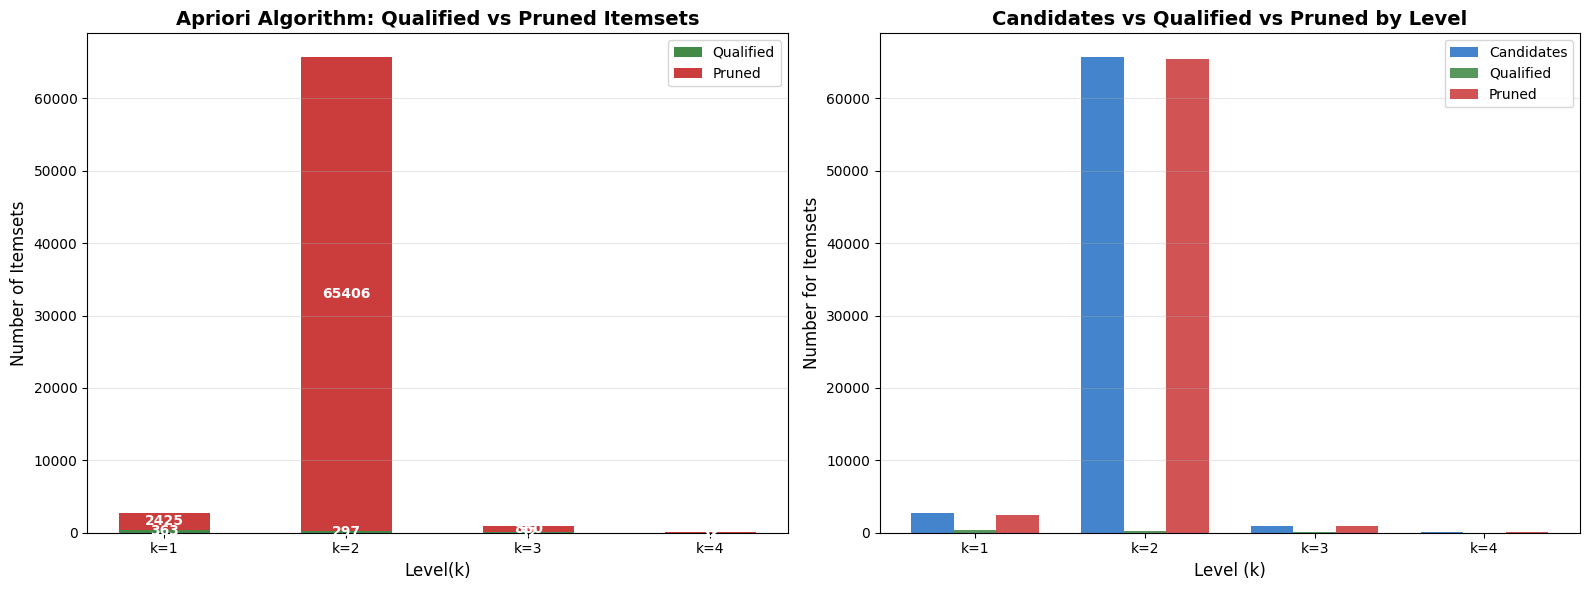

In [21]:
# Visualization: Candidate vs Qualified vs. Pruned at each level

# Create visualization of the Apriori process
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


levels = list(level_stats.keys())
qualified = [level_stats[l]['qualified'] for l in levels]
pruned = [level_stats[l]['pruned'] for l in levels]
candidates = [level_stats[l]['candidates'] for l in levels]

x = np.arange(len(levels))
width = 0.25

# Plot 1: stacked bar chart
axes[0].bar(x, qualified, width*2, label='Qualified', color='#2E7D32', alpha=0.9)
axes[0].bar(x, pruned, width*2, bottom=qualified, label='Pruned', color='#C62828', alpha=0.9)
axes[0].set_xlabel('Level(k)', fontsize=12)
axes[0].set_ylabel('Number of Itemsets', fontsize=12)
axes[0].set_title('Apriori Algorithm: Qualified vs Pruned Itemsets', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'k={l}' for l in levels])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (q, p) in enumerate(zip(qualified, pruned)):
    axes[0].text(i, q/2, str(q), ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if p > 0:
        axes[0].text(i, q + p/2, str(p), ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Plot 2: Grouped bar chart
axes[1].bar(x - width, candidates, width, label='Candidates', color='#1565C0', alpha=0.8)
axes[1].bar(x, qualified, width, label='Qualified', color='#2E7D32', alpha=0.8)
axes[1].bar(x + width, pruned, width, label='Pruned', color='#C62828', alpha=0.8)
axes[1].set_xlabel('Level (k)', fontsize=12)
axes[1].set_ylabel('Number for Itemsets', fontsize=12)
axes[1].set_title('Candidates vs Qualified vs Pruned by Level', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'k={l}' for l in levels])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)


# Save and show created visualization
plt.tight_layout()
plt.savefig('../visuals/standard_apriori_level_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# 2.3b. Identify Strong and Wak association rules
def generate_association_rules(frequent_itemsets, min_confidence, total_transactions, verbose=True):
    """
    Generate association rules from frequent itemsets

    Parameters:
    frequent_itemsets: dict - all frequent itemsets with their support counts
    min_confidence: float - minimum confidence threshold (0-1)
    total_trasactions: int - total number of transactions
    verbose: bool - print detailed output

    Returns:
    strong rules: list - rules with confidence >= min_confidence
    weak_rules: list - rules with < min_confidence
    """

    strong_rules = []
    weak_rules = []

    for itemset, support_count in frequent_itemsets.items():
        # skip 1-itemsets as it cannot form rules
        if len(itemset) < 2: 
            continue

        # Generate possible rules from this itemset
        for i in range(1, len(itemset)):
            for antecedent_items in itertools.combinations(itemset, i):
                antecedent = frozenset(antecedent_items)
                consequent = itemset - antecedent

            # Calculate for confidence
                antecedent_support = frequent_itemsets.get(antecedent, 0)

                if antecedent_support > 0:
                    confidence = support_count / antecedent_support

                    # Calculate lift
                    consequent_support = frequent_itemsets.get(consequent, 0)
                    expected_confidence = consequent_support / total_transactions
                    lift = confidence / expected_confidence if expected_confidence > 0 else 0 

                    rule = {
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support_count': support_count,
                        'support': support_count / total_transactions,
                        'confidence': confidence,
                        'lift': lift
                    }

                    # Populate strong / weak rules lists
                    if confidence >= min_confidence:
                        strong_rules.append(rule)
                    else:
                        weak_rules.append(rule)
        
    # Sort lists by confidence
    strong_rules.sort(key=lambda x: x['confidence'], reverse=True)
    weak_rules.sort(key=lambda x: x['confidence'], reverse=True)

    if verbose:
        print("=" * 80)
        print("ASSOCIATION RULE GENERATION: ")
        print("=" * 80)
        print(f"Confidence Threshold: {min_confidence * 100}%")
        print(f"Total Rules Generated: {len(strong_rules) + len(weak_rules)}")
        print(f"  - Strong Rules (Confidence >= {min_confidence*100}%): {len(strong_rules)}")
        print(f"  - Weak Rules (Confidence >= {min_confidence*100}%): {len(weak_rules)}")

        # Display Top 10 Strong Rules
        print("\n" + "=" * 80)
        print("TOP 10 STRONG ASSOCIATION RULES: ")
        print("=" * 80)

        print(f"{'Rank':<6} {'Rule': <60} {'Supp': <8} {'Conf':<8} {'Lift':<8}")
        print("-" * 80)

        for i, rule in enumerate(strong_rules[:10], 1):
            strong_ant_str = ', '.join(list(rule['antecedent']))[:25]
            strong_cons_str = ', '.join(list(rule['consequent']))[:25]
            strong_rule_str= f"{{{strong_ant_str}}} -> {{{strong_cons_str}}}"
            print(f"{i:<6} {strong_rule_str:<60} {rule['support']*100:<7.2f}% {rule['confidence']*100:<7.2f}% {rule['lift']:7.2f}")

        # Display Top 10 Weak Rules
        print("\n" + "=" * 80)
        print("TOP 10 WEAK ASSOCIATION RULES: ")
        print("=" * 80)

        print(f"{'Rank':<6} {'Rule': <60} {'Supp': <8} {'Conf':<8} {'Lift':<8}")
        print("-" * 80)

        for i, rule in enumerate(weak_rules[:10], 1):
            weak_ant_str = ', '.join(list(rule['antecedent']))[:25]
            weak_cons_str = ', '.join(list(rule['consequent']))[:25]
            weak_rule_str= f"{{{weak_ant_str}}} -> {{{weak_cons_str}}}"
            print(f"{i:<6} {weak_rule_str:<60} {rule['support']*100:<7.2f}% {rule['confidence']*100:<7.2f}% {rule['lift']:7.2f}")

        # Create summary table
        summary_data = {
            'Metric': [
                'Total Transactions',
                'Minimum Support',
                'Minimum Confidence',
                'Total Frequent Itemsets',
                'Total Rules Generated',
                'Strong Rules (>=80%)',
                'Weak Rules (<80%)',
                'Execution Time (seconds)'
            ],
            'Value': [
                f"{total_transactions:,}",
                f"{MIN_SUPPORT * 100}% {min_support_count} transactions",
                f"{MIN_CONFIDENCE * 100}%",
                f"{len(all_frequent_itemsets)}",
                f"{len(strong_rules) + len(weak_rules)}",
                f"{len(strong_rules)}",
                f"{len(weak_rules)}",
                f"{exec_time:.4f}"
            ]
        }

        summary_df = pd.DataFrame(summary_data)

        print("=" * 80)
        print("EXECUTION SUMMARY TABLE: ")
        print("=" * 80)
        print(summary_df.to_string(index=False))
    
    return strong_rules, weak_rules 
    
# Run the function
strong_rules, weak_rules = generate_association_rules (
    all_frequent_itemsets, MIN_CONFIDENCE, total_transactions, verbose=True
)

ASSOCIATION RULE GENERATION: 
Confidence Threshold: 80.0%
Total Rules Generated: 786
  - Strong Rules (Confidence >= 80.0%): 31
  - Weak Rules (Confidence >= 80.0%): 755

TOP 10 STRONG ASSOCIATION RULES: 
Rank   Rule                                                         Supp     Conf     Lift    
--------------------------------------------------------------------------------
1      {ALARM CLOCK BAKELIKE ORAN} -> {ALARM CLOCK BAKELIKE GREE}   2.28   % 97.62  %   14.42
2      {CHRISTMAS TREE DECORATION} -> {CHRISTMAS TREE HEART DECO}   2.05   % 92.50  %   38.76
3      {CHRISTMAS TREE DECORATION} -> {CHRISTMAS TREE STAR DECOR}   2.00   % 90.00  %   36.86
4      {ALARM CLOCK BAKELIKE RED,} -> {ALARM CLOCK BAKELIKE GREE}   2.44   % 89.80  %   13.26
5      {SCOTTIE DOG HOT WATER BOT} -> {CHOCOLATE HOT WATER BOTTL}   2.66   % 88.89  %    9.95
6      {POPPY'S PLAYHOUSE KITCHEN} -> {POPPY'S PLAYHOUSE BEDROOM}   2.22   % 88.89  %   22.56
7      {REGENCY CAKESTAND 3 TIER,} -> {PAPER CHAIN KIT 

LEVEL-WISE ANALYSIS TABLE: 
 Level (k)  Candidates  Qualified  Pruned Pruning Rate
         1        2788        363    2425        87.0%
         2       65703        297   65406        99.5%
         3         892         32     860        96.4%
         4          32          0      32       100.0%

Note: Pruning Rate = Pruned / Candidates * 100%


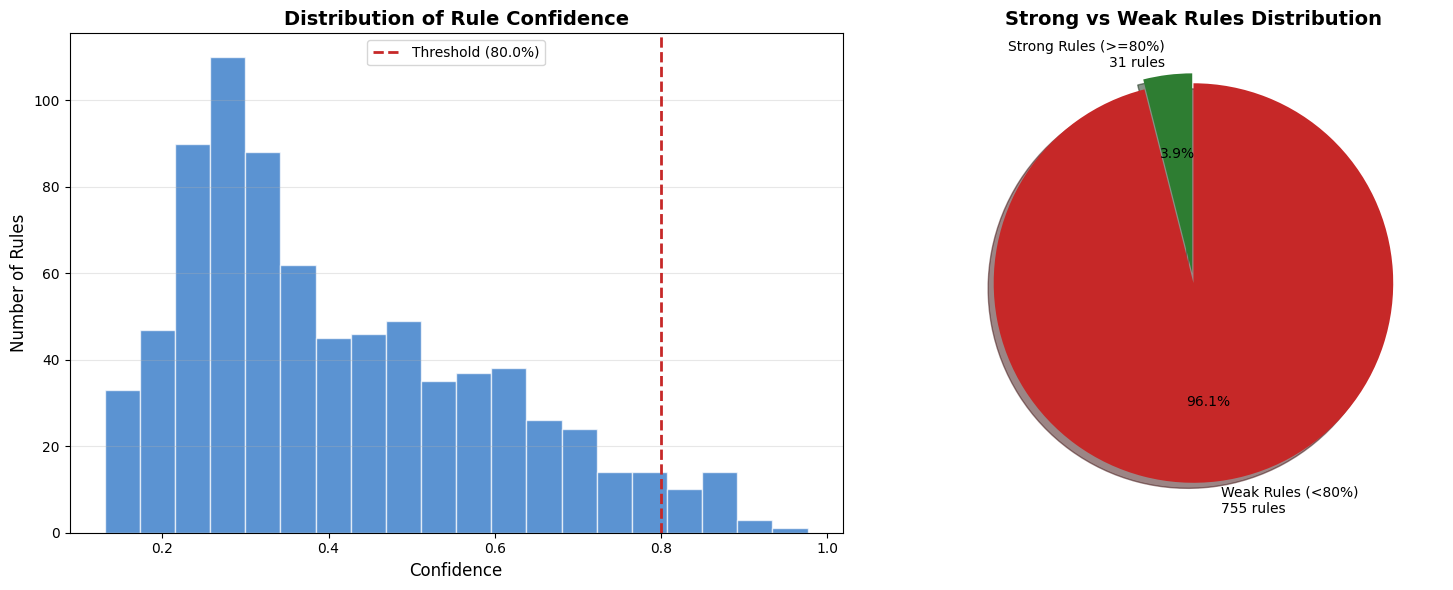

In [27]:
# Additional Level-Wise Detailed Analytics and Confidence Distribution Visuals

# Create level-wise summary table
level_data = {
    'Level (k)': [],
    'Candidates': [],
    'Qualified': [],
    'Pruned': [],
    'Pruning Rate': []
}

for level, stats in level_stats.items():
    level_data['Level (k)'].append(level)
    level_data['Candidates'].append(stats['candidates'])
    level_data['Qualified'].append(stats['qualified'])
    level_data['Pruned'].append(stats['pruned'])
    pruning_rate = (stats['pruned'] / stats['candidates'] * 100) if stats['candidates'] > 0 else 0
    level_data['Pruning Rate'].append(f"{pruning_rate:.1f}%")

level_df = pd.DataFrame(level_data)

print("=" * 80)
print("LEVEL-WISE ANALYSIS TABLE: ")
print("=" * 80)
print(level_df.to_string(index=False))
print("\nNote: Pruning Rate = Pruned / Candidates * 100%")

# Create confidence distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All rules confidence distro
all_confidences = [r['confidence'] for r in strong_rules + weak_rules]

axes[0].hist(all_confidences, bins=20, color='#1565C0', edgecolor='white', alpha=0.7)
axes[0].axvline(x=MIN_CONFIDENCE, color='#C62828', linestyle='--', linewidth='2', label=f'Threshold ({MIN_CONFIDENCE*100}%)')
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Number of Rules', fontsize=12)
axes[0].set_title('Distribution of Rule Confidence', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Strong vs weak rules pie chart
sizes = [len(strong_rules), len(weak_rules)]
labels = [f'Strong Rules (>=80%)\n{len(strong_rules)} rules', f'Weak Rules (<80%)\n{len(weak_rules)} rules']
colors = ['#2E7D32', '#C62828']
explode = (0.05, 0)

axes[1].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
axes[1].set_title('Strong vs Weak Rules Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/association_rules_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_11988\1658295949.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=[f'Level {k}' for k in sorted_levels], patch_artist=True)


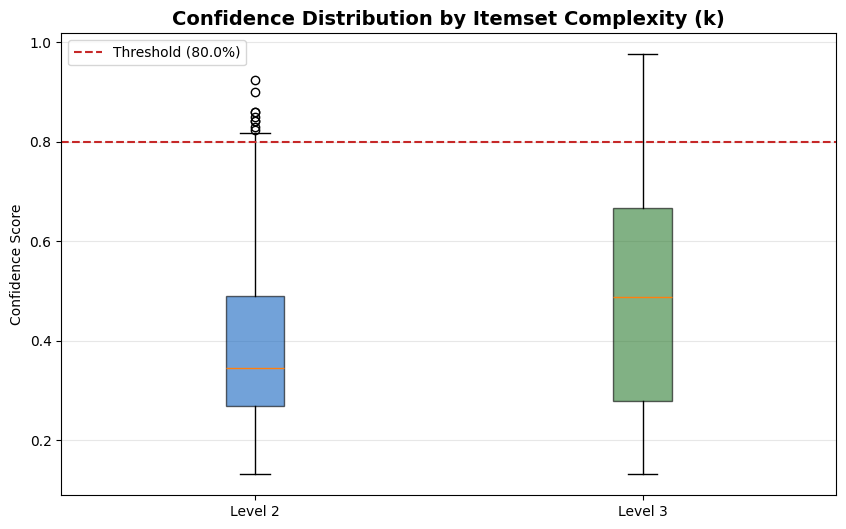

In [ ]:
# Visulaize confidence scores distribution at each level

# 1. Group rules by k-level
rules_by_level = {}
for rule in strong_rules + weak_rules:
    k = len(rule['antecedent']) + len(rule['consequent'])
    if k not in rules_by_level:
        rules_by_level[k] = []
    rules_by_level[k].append(rule['confidence'])

# 2. Sort levels for plotting
sorted_levels = sorted(rules_by_level.keys())
if sorted_levels:
    plt.figure(figsize=(10, 6))
    data_to_plot = [rules_by_level[k] for k in sorted_levels]
    
    # Create the boxplot
    bp = plt.boxplot(data_to_plot, labels=[f'Level {k}' for k in sorted_levels], patch_artist=True)
    
    # Styling
    colors = ['#1565C0', '#2E7D32', '#EF6C00', '#6A1B9A']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    plt.axhline(y=MIN_CONFIDENCE, color='#C62828', linestyle='--', label=f'Threshold ({MIN_CONFIDENCE*100}%)')
    plt.title('Confidence Distribution by Itemset Complexity (k)', fontsize=14, fontweight='bold')
    plt.ylabel('Confidence Score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    plt.savefig('../visuals/standard_confidence_by_level_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()